In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Resume Screening System using NLP and Machine Learning

## Objective

To automatically screen resumes, rank candidates, and identify missing skills using NLP and machine learning techniques.

## Business Insights

- Automated screening reduces manual recruitment effort.
- Candidate ranking improves hiring efficiency.
- Skill gap identification helps recruiters shortlist better candidates.

In [1]:
import pandas as pd

data = {
    'Resume': [
        'Python SQL Machine Learning Data Analysis',
        'Java Spring Boot Microservices',
        'Python Deep Learning NLP TensorFlow',
        'HTML CSS JavaScript React',
        'Python SQL Power BI Tableau'
    ],
    
    'Candidate_Name': [
        'John',
        'David',
        'Emma',
        'Sophia',
        'Michael'
    ]
}

df = pd.DataFrame(data)

df

,Resume,Candidate_Name
0,Python SQL Machine Learning Data Analysis,John
1,Java Spring Boot Microservices,David
2,Python Deep Learning NLP TensorFlow,Emma
3,HTML CSS JavaScript React,Sophia
4,Python SQL Power BI Tableau,Michael


In [2]:
job_description = "Python SQL Machine Learning Data Analysis"

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [6]:
documents = list(df['Resume'])

documents.append(job_description)

vectorizer = TfidfVectorizer()

matrix = vectorizer.fit_transform(documents)

In [7]:
similarity = cosine_similarity(matrix[-1], matrix[:-1])

similarity

array([[1.        , 0.        , 0.23279994, 0.        , 0.23279994]])

In [8]:
df['Score'] = similarity[0]

df

,Resume,Candidate_Name,Score
0,Python SQL Machine Learning Data Analysis,John,1.0000
1,Java Spring Boot Microservices,David,0.0000
2,Python Deep Learning NLP TensorFlow,Emma,0.2328
3,HTML CSS JavaScript React,Sophia,0.0000
4,Python SQL Power BI Tableau,Michael,0.2328


In [9]:
ranked_df = df.sort_values(by='Score', ascending=False)

ranked_df

,Resume,Candidate_Name,Score
0,Python SQL Machine Learning Data Analysis,John,1.0000
2,Python Deep Learning NLP TensorFlow,Emma,0.2328
4,Python SQL Power BI Tableau,Michael,0.2328
1,Java Spring Boot Microservices,David,0.0000
3,HTML CSS JavaScript React,Sophia,0.0000


In [10]:
required_skills = set(job_description.lower().split())

required_skills

{'analysis', 'data', 'learning', 'machine', 'python', 'sql'}

In [11]:
def missing_skills(resume):
    
    resume_skills = set(resume.lower().split())
    
    missing = required_skills - resume_skills
    
    return ', '.join(missing)

df['Missing_Skills'] = df['Resume'].apply(missing_skills)

df

,Resume,Candidate_Name,Score,Missing_Skills
0,Python SQL Machine Learning Data Analysis,John,1.0000,
1,Java Spring Boot Microservices,David,0.0000,"learning, data, sql, python, analysis, machine"
2,Python Deep Learning NLP TensorFlow,Emma,0.2328,"machine, sql, data, analysis"
3,HTML CSS JavaScript React,Sophia,0.0000,"learning, data, sql, python, analysis, machine"
4,Python SQL Power BI Tableau,Michael,0.2328,"learning, analysis, data, machine"


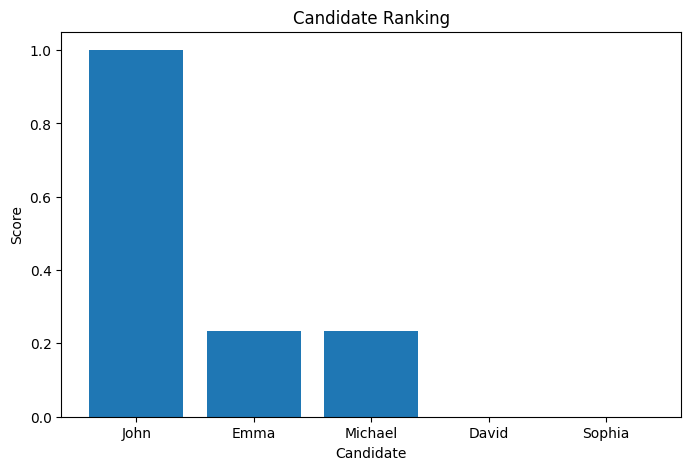

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(ranked_df['Candidate_Name'], ranked_df['Score'])

plt.title('Candidate Ranking')

plt.xlabel('Candidate')

plt.ylabel('Score')

plt.show()

In [13]:
best_candidate = ranked_df.iloc[0]

print("Best Candidate:")
print(best_candidate)

Best Candidate:
Resume            Python SQL Machine Learning Data Analysis
Candidate_Name                                         John
Score                                                   1.0
Name: 0, dtype: object


## Conclusion

The project successfully ranks resumes and identifies missing skills using NLP and machine learning techniques.